# EE519 — Notebook 1: Classical Speech Emotion Recognition Pipeline

## Overview
1. **Download and explore** the RAVDESS dataset (publicly available)
2. **Visualize** waveforms, spectrograms, pitch contours, MFCC heatmaps
3. **Extract acoustic features** using `librosa`
4. **Build classifiers**: SVM, Random Forest
5. **Evaluate**: confusion matrix, classification report, UAR

### References
- Livingstone & Russo (2018). RAVDESS. *PLoS ONE*.
- Eyben et al. (2016). eGeMAPS. *IEEE TAC*.
- McFee et al. (2015). librosa. *SciPy*.

In [1]:
# Install dependencies
# !pip install librosa numpy scikit-learn matplotlib seaborn soundfile tqdm

In [8]:
import os, glob, numpy as np, librosa, librosa.display
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from collections import Counter
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('All imports successful!')

All imports successful!


## 1. Load & Explore RAVDESS

**RAVDESS** — 24 actors, 1440 speech files, 8 emotions, 2 intensities.

Filename convention: `03-01-05-01-01-01-12.wav`
- Pos 3 = **Emotion**: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised
- Pos 7 = Actor (odd=male, even=female)

Download from: https://zenodo.org/record/1188976

In [ ]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name in ("notebooks_claude", "notebooks")
    else NOTEBOOK_DIR
)
RAVDESS_DIR = str(PROJECT_ROOT / "data" / "ravdess")
assert Path(RAVDESS_DIR).is_dir(), f"Missing {RAVDESS_DIR} — run scripts/download_kaggle_ravdess.py"
_wavs = list(Path(RAVDESS_DIR).glob("**/*.wav"))

assert _wavs, f"No WAV files under {RAVDESS_DIR}"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAVDESS_DIR:", RAVDESS_DIR, "| wav count:", len(_wavs))


EMOTION_MAP = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

def parse_ravdess(filepath):
    parts = os.path.basename(filepath).replace('.wav','').split('-')
    return {'filepath': filepath, 'emotion_code': parts[2],
            'emotion': EMOTION_MAP.get(parts[2],'unknown'),
            'intensity': 'normal' if parts[3]=='01' else 'strong',
            'actor_id': int(parts[6]),
            'gender': 'male' if int(parts[6])%2==1 else 'female'}

audio_files = sorted(glob.glob(os.path.join(RAVDESS_DIR, '**', '*.wav'), recursive=True))
data = [parse_ravdess(f) for f in audio_files
        if os.path.basename(f).split('-')[0]=='03' and os.path.basename(f).split('-')[1]=='01']

print(f'Total speech files: {len(data)}')
if data:
    print(f'Emotion distribution: {dict(Counter([d["emotion"] for d in data]))}')
    import os as _os
    _cap = (_os.environ.get('SER_CLAUDE_MAX_SAMPLES') or '250').strip()
    if _cap not in ('', '0') and len(data) > int(_cap):
        data = data[:int(_cap)]
        print(f'Subset for runtime: {len(data)} files (full set: unset SER_CLAUDE_MAX_SAMPLES or set 0)')
else:
    print('No files found. Please set RAVDESS_DIR correctly.')

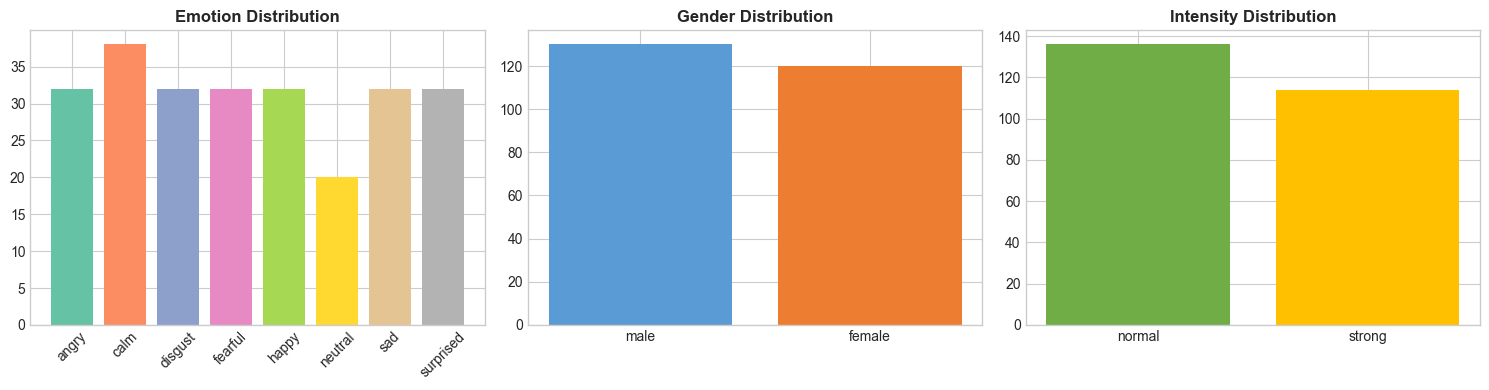

In [23]:
# Dataset statistics
if data:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    emo_counts = Counter([d['emotion'] for d in data])
    axes[0].bar(sorted(emo_counts.keys()), [emo_counts[e] for e in sorted(emo_counts.keys())], color=sns.color_palette('Set2', 8))
    axes[0].set_title('Emotion Distribution', fontweight='bold'); axes[0].tick_params(axis='x', rotation=45)
    gen = Counter([d['gender'] for d in data])
    axes[1].bar(gen.keys(), gen.values(), color=['#5B9BD5','#ED7D31'])
    axes[1].set_title('Gender Distribution', fontweight='bold')
    inten = Counter([d['intensity'] for d in data])
    axes[2].bar(inten.keys(), inten.values(), color=['#70AD47','#FFC000'])
    axes[2].set_title('Intensity Distribution', fontweight='bold')
    plt.tight_layout(); plt.show()

## 2. Visualize Audio Signals

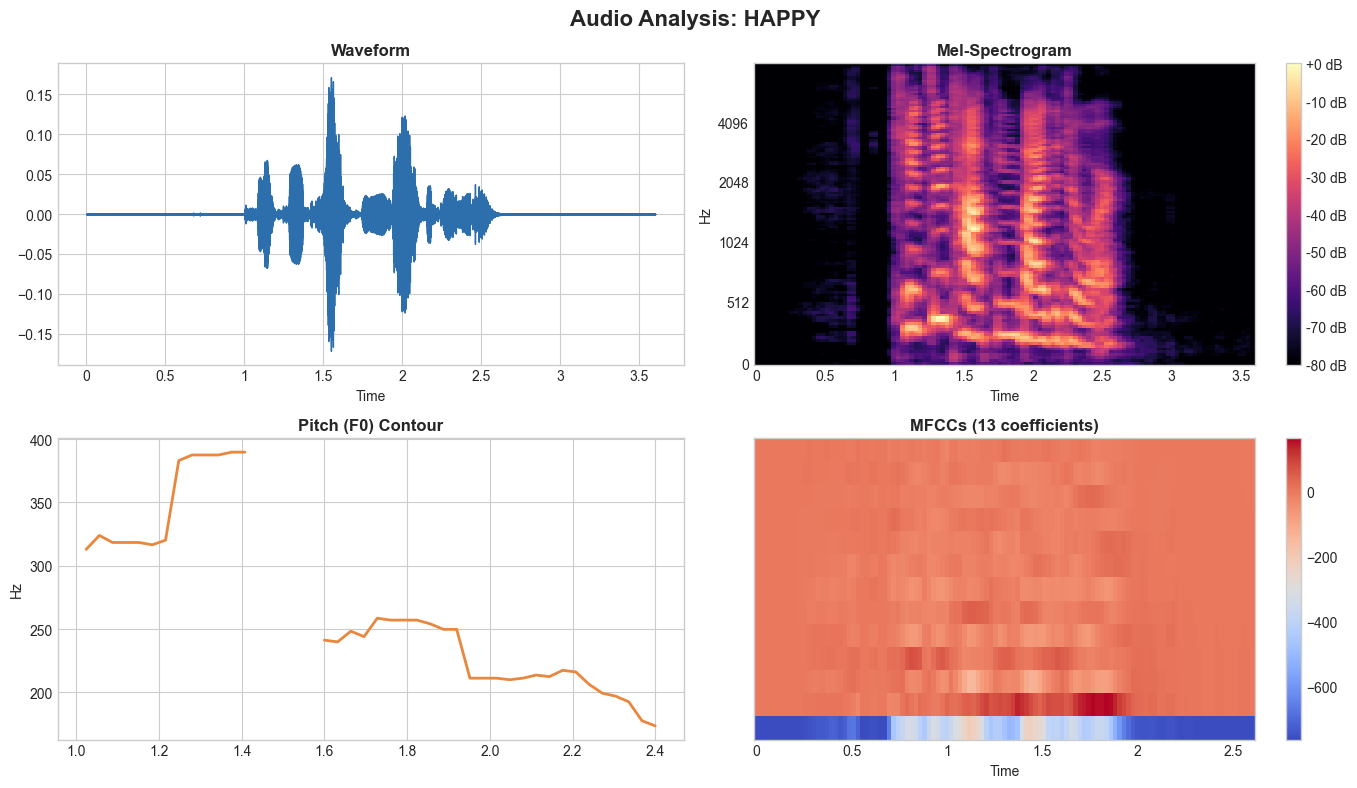

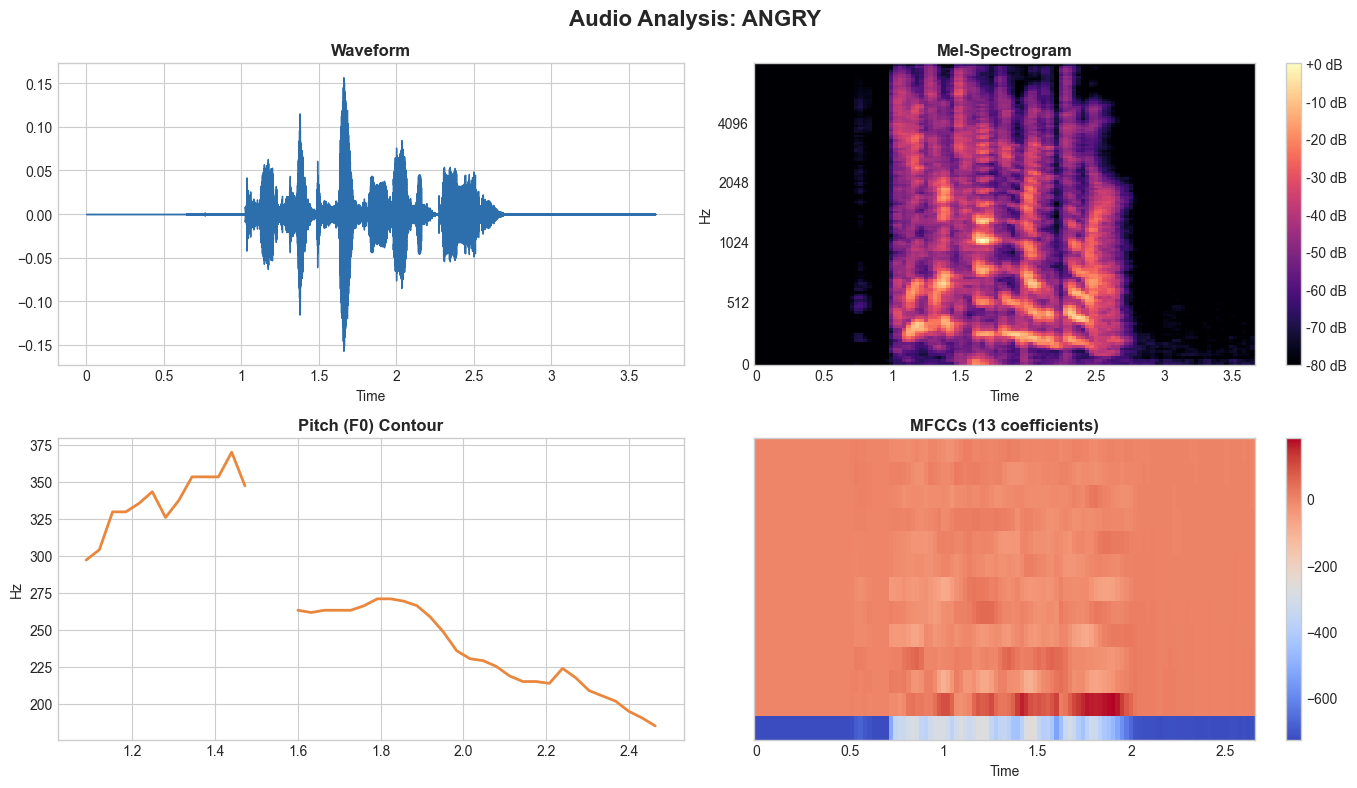

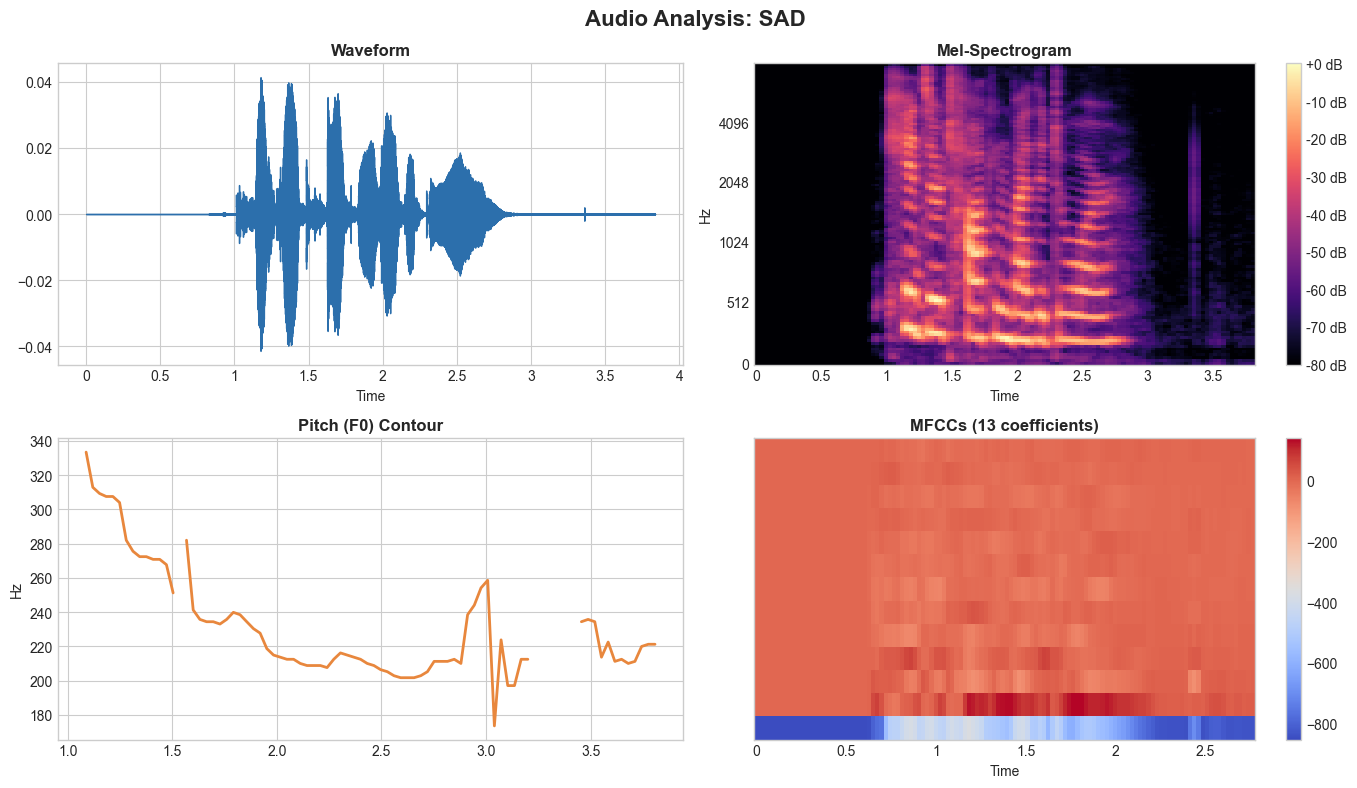

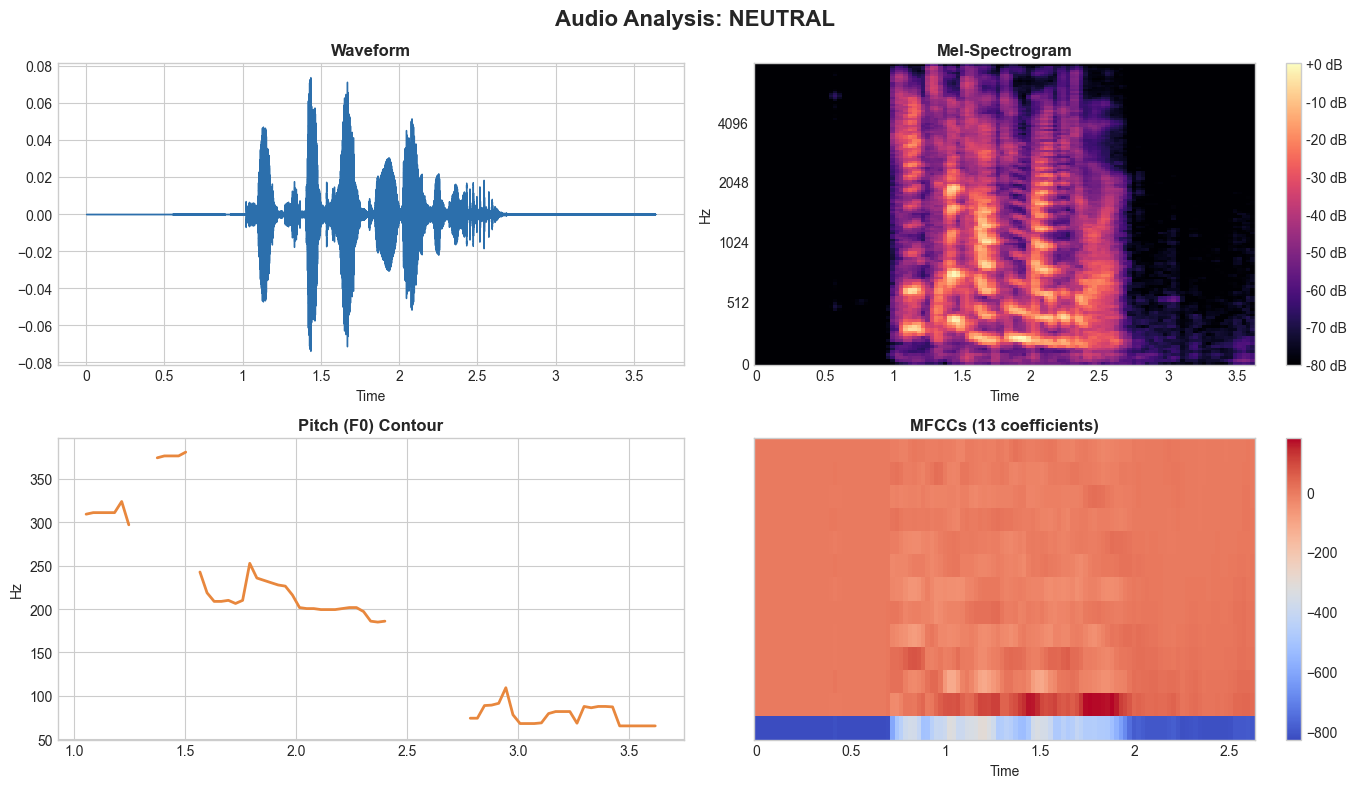

In [24]:
def visualize_audio(filepath, emotion_label, sr=16000):
    y, sr = librosa.load(filepath, sr=sr)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Audio Analysis: {emotion_label.upper()}', fontsize=16, fontweight='bold')
    
    librosa.display.waveshow(y, sr=sr, ax=axes[0,0], color='#2C6FAC')
    axes[0,0].set_title('Waveform', fontweight='bold')
    
    S_dB = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000), ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=axes[0,1], cmap='magma')
    axes[0,1].set_title('Mel-Spectrogram', fontweight='bold'); fig.colorbar(img, ax=axes[0,1], format='%+2.0f dB')
    
    f0, _, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr)
    axes[1,0].plot(librosa.times_like(f0, sr=sr), f0, color='#E8873D', linewidth=2)
    axes[1,0].set_title('Pitch (F0) Contour', fontweight='bold'); axes[1,0].set_ylabel('Hz')
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img2 = librosa.display.specshow(mfccs, x_axis='time', ax=axes[1,1], cmap='coolwarm')
    axes[1,1].set_title('MFCCs (13 coefficients)', fontweight='bold'); fig.colorbar(img2, ax=axes[1,1])
    plt.tight_layout(); plt.show()

if data:
    for emo in ['happy', 'angry', 'sad', 'neutral']:
        sample = next((d for d in data if d['emotion']==emo and d['gender']=='female'), None)
        if sample: visualize_audio(sample['filepath'], emo)

## 3. Feature Extraction (eGeMAPS-inspired)

In [25]:
def extract_features(filepath, sr=16000):
    y, sr = librosa.load(filepath, sr=sr)
    features = []
    # MFCCs + Delta + Delta-Delta
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for feat in [mfccs, librosa.feature.delta(mfccs), librosa.feature.delta(mfccs, order=2)]:
        features.extend(np.mean(feat, axis=1)); features.extend(np.std(feat, axis=1))
    # Mel-Spectrogram stats
    mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64))
    features.extend(np.mean(mel_db, axis=1)); features.extend(np.std(mel_db, axis=1))
    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.extend(np.mean(chroma, axis=1)); features.extend(np.std(chroma, axis=1))
    # Spectral features
    for feat in [librosa.feature.spectral_centroid(y=y,sr=sr), librosa.feature.spectral_bandwidth(y=y,sr=sr),
                 librosa.feature.spectral_rolloff(y=y,sr=sr), librosa.feature.spectral_flatness(y=y)]:
        features.extend([np.mean(feat), np.std(feat)])
    sc = librosa.feature.spectral_contrast(y=y, sr=sr)
    features.extend(np.mean(sc, axis=1)); features.extend(np.std(sc, axis=1))
    # Prosodic: F0
    f0, _, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr)
    f0v = f0[~np.isnan(f0)] if f0 is not None else np.array([0])
    if len(f0v)==0: f0v = np.array([0])
    features.extend([np.mean(f0v), np.std(f0v), np.min(f0v), np.max(f0v), np.ptp(f0v)])
    # RMS, ZCR, Tempo, Duration
    rms = librosa.feature.rms(y=y); features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    zcr = librosa.feature.zero_crossing_rate(y); features.extend([np.mean(zcr), np.std(zcr)])
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features.append(float(tempo) if np.isscalar(tempo) else float(tempo[0]) if len(tempo)>0 else 120.0)
    features.append(len(y)/sr)
    return np.array(features, dtype=np.float32)

if data:
    test_feat = extract_features(data[0]['filepath'])
    print(f'Feature vector dimension: {test_feat.shape[0]}')

Feature vector dimension: 264


In [26]:
X_all, y_all, actor_ids = [], [], []
print('Extracting features...')
for d in tqdm(data):
    try:
        X_all.append(extract_features(d['filepath'])); y_all.append(d['emotion'])
        actor_ids.append(d['actor_id'])
    except Exception as e:
        print(f"Error: {e}")
X = np.nan_to_num(np.array(X_all)); y = np.array(y_all)
groups = np.asarray(actor_ids, dtype=np.int64)
print(f'Feature matrix: {X.shape}, Labels: {y.shape}')

Extracting features...


100%|██████████| 250/250 [03:41<00:00,  1.13it/s]

Feature matrix: (250, 264), Labels: (250,)


## 4. Classification: SVM & Random Forest

**Subject-independent evaluation:** cross-validation uses **`StratifiedGroupKFold`** with `groups = actor_id` (RAVDESS speaker). Training and test folds never share the same speaker, so accuracy reflects generalization to unseen subjects.

In [27]:
le = LabelEncoder(); y_enc = le.fit_transform(y); class_names = le.classes_
n_spk = len(np.unique(groups))
n_splits = min(5, n_spk)
if n_splits < 2:
    raise ValueError('Need at least 2 distinct speakers for subject-independent CV.')
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f'Subject-independent CV: StratifiedGroupKFold, n_splits={n_splits}, distinct actors={n_spk}')

# SVM
svm_pipe = Pipeline([('scaler',StandardScaler()), ('svm',SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced'))])
y_pred_svm = cross_val_predict(svm_pipe, X, y_enc, cv=cv, groups=groups)
uar_svm = balanced_accuracy_score(y_enc, y_pred_svm)
acc_svm = accuracy_score(y_enc, y_pred_svm)
print(f'SVM — UAR: {uar_svm:.3f}, Accuracy: {acc_svm:.3f}')
print(classification_report(y_enc, y_pred_svm, target_names=class_names, digits=3))

# Random Forest
rf_pipe = Pipeline([('scaler',StandardScaler()), ('rf',RandomForestClassifier(n_estimators=300,max_depth=20,class_weight='balanced',random_state=42,n_jobs=-1))])
y_pred_rf = cross_val_predict(rf_pipe, X, y_enc, cv=cv, groups=groups)
uar_rf = balanced_accuracy_score(y_enc, y_pred_rf)
acc_rf = accuracy_score(y_enc, y_pred_rf)
print(f'RF — UAR: {uar_rf:.3f}, Accuracy: {acc_rf:.3f}')
print(classification_report(y_enc, y_pred_rf, target_names=class_names, digits=3))

Subject-independent CV: StratifiedGroupKFold, n_splits=5, distinct actors=5
SVM — UAR: 0.401, Accuracy: 0.408
              precision    recall  f1-score   support

       angry      0.500     0.688     0.579        32
        calm      0.500     0.289     0.367        38
     disgust      0.417     0.312     0.357        32
     fearful      0.500     0.750     0.600        32
       happy      0.500     0.312     0.385        32
     neutral      0.121     0.200     0.151        20
         sad      0.121     0.125     0.123        32
   surprised      0.654     0.531     0.586        32

    accuracy                          0.408       250
   macro avg      0.414     0.401     0.393       250
weighted avg      0.430     0.408     0.404       250

RF — UAR: 0.442, Accuracy: 0.448
              precision    recall  f1-score   support

       angry      0.515     0.531     0.523        32
        calm      0.471     0.421     0.444        38
     disgust      0.489     0.688     0.571

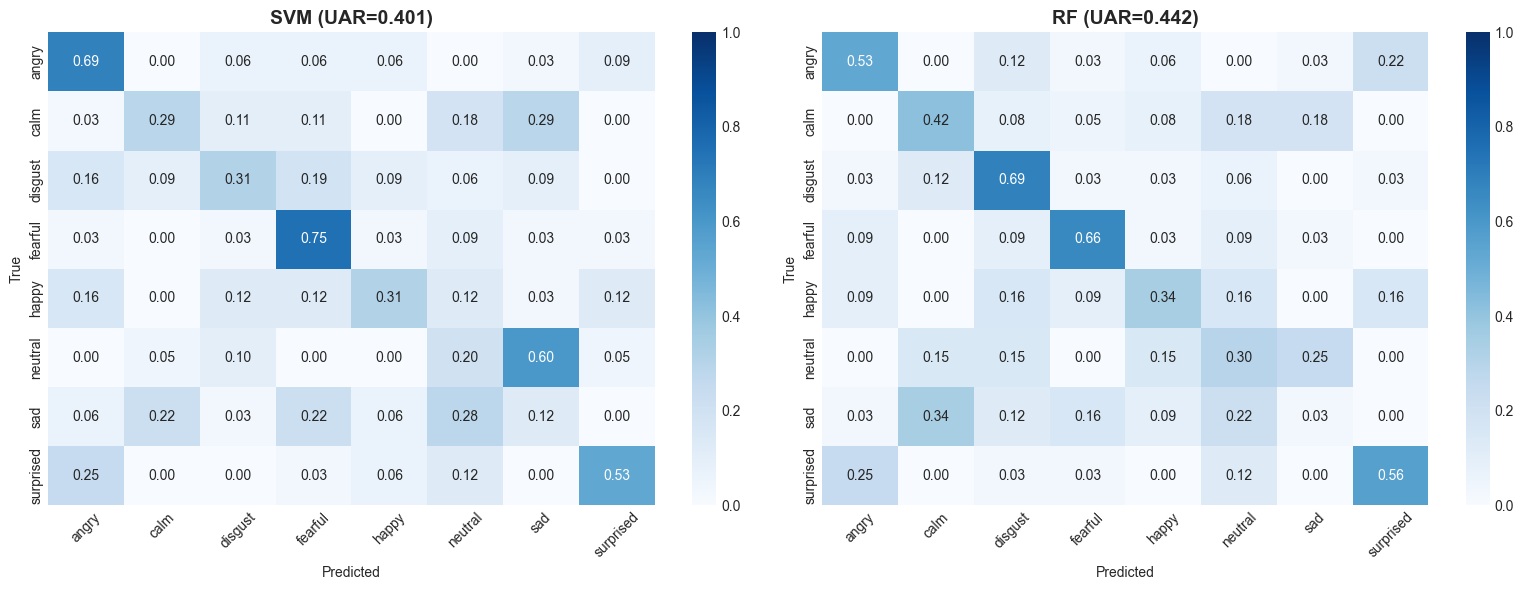

In [28]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, yp, title in [(axes[0],y_pred_svm,f'SVM (UAR={uar_svm:.3f})'), (axes[1],y_pred_rf,f'RF (UAR={uar_rf:.3f})')]:
    cm = confusion_matrix(y_enc, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontsize=14, fontweight='bold'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 5. Feature Space Visualization (t-SNE)

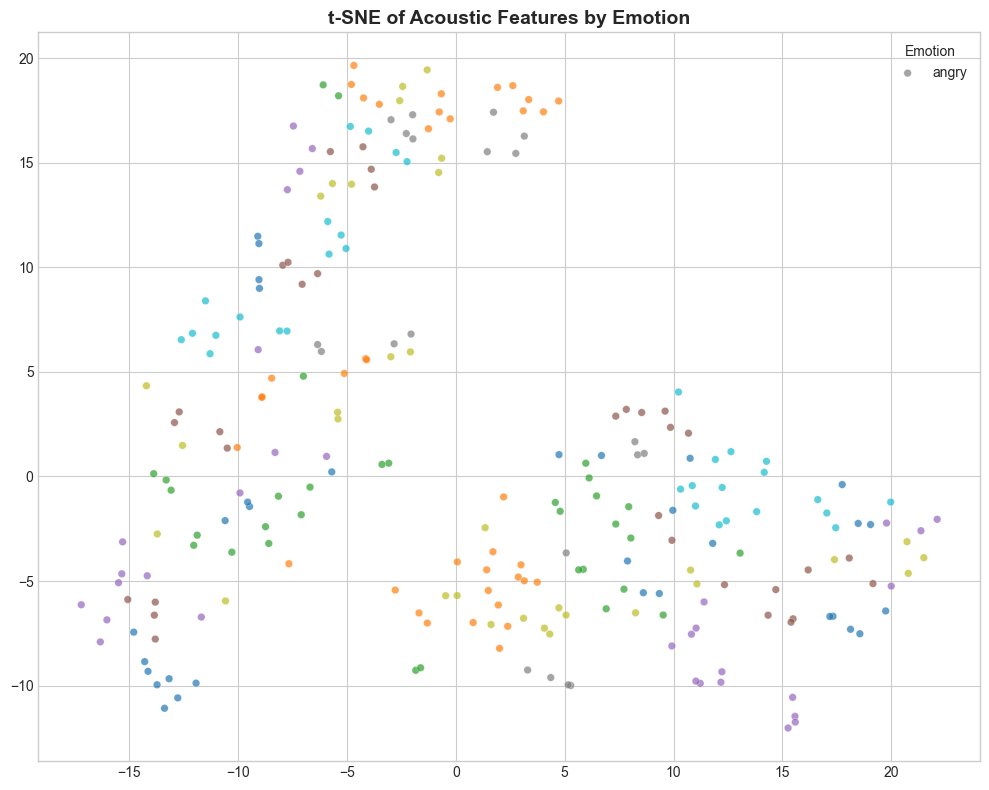

In [29]:
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(StandardScaler().fit_transform(X))
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_enc, cmap='tab10', alpha=0.7, s=30, edgecolors='white', linewidth=0.3)
plt.legend(*scatter.legend_elements(), title='Emotion', labels=list(class_names))
plt.title('t-SNE of Acoustic Features by Emotion', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary
- Classical features + SVM/RF achieve reasonable results on acted speech
- Some emotions commonly confused (calm/neutral, happy/surprised)
- **Next: Notebook 2** — Foundation models (Wav2Vec2) that learn features from raw waveforms